Name: **your name here**

In [6]:
# Show all output of one executed cell:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import matplotlib.pyplot as plt

# Wrap up day 1

Welcome back again.  
Yesterday you learned several core concepts of running COBRA.
You
- installed a conda virtual environment and setup COBRA to run constraint-based modeling (CBM) tasks
- learned about essential metabolic model components
- learned and used core concepts for flux computations including FBA and FVA

Along the way, you
- [refreshed|gained] knowledge of the python programming language
- [refreshed|gained] experience with using jupyter notebooks, a popular tool in data science
- gained experience with reading package documentation
- gained experience in writing content to Markdown, a popular and simple tool towards formatting documentation for the web

---

# Today

Instead of reconstructing a metabolic model from scratch, we will concentrate on model simulation and analysis instead.  

We will investigate  
- exchange reactions and media components,
- investigate flux range dependent objective yield,
- production envelopes,
- investigate unique results towards target metabolites,
- (model consistency),
- (learn about flux sampling).

---

## Task 1: Model loading

- Load cobrapy and the textbook *Escherichia coli* model (<code>load_model()</code>  function of the cobra.io module with "textbook" as argument)
    - name your model "m_eco_core"
    - save the model's default media composition to a variable for later purposes
- Print the string representation of the model instance to the console
- Print the details of the metabolic reaction of the default objective function to the screen


In [7]:
## your code ##
## load packages
import cobra
from cobra.io import load_model

## load model
m_eco_core = load_model("textbook")
# m_eco_full = load_model("iJO1366") # https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3261703/
# m_salm = load_model("salmonella") # https://www.nature.com/articles/s41467-018-06112-5#additional-information

## model details
m_eco_core
m_eco_core_media = m_eco_core.medium 
## details objective function
m_eco_core.reactions.Biomass_Ecoli_core.reaction
## --- ##

Name,e_coli_core
Memory address,7f21448efbd0
Number of metabolites,72
Number of reactions,95
Number of genes,137
Number of groups,0
Objective expression,1.0*Biomass_Ecoli_core - 1.0*Biomass_Ecoli_core_reverse_2cdba
Compartments,"cytosol, extracellular"


'1.496 3pg_c + 3.7478 accoa_c + 59.81 atp_c + 0.361 e4p_c + 0.0709 f6p_c + 0.129 g3p_c + 0.205 g6p_c + 0.2557 gln__L_c + 4.9414 glu__L_c + 59.81 h2o_c + 3.547 nad_c + 13.0279 nadph_c + 1.7867 oaa_c + 0.5191 pep_c + 2.8328 pyr_c + 0.8977 r5p_c --> 59.81 adp_c + 4.1182 akg_c + 3.7478 coa_c + 59.81 h_c + 3.547 nadh_c + 13.0279 nadp_c + 59.81 pi_c'

Does this model reflect all of E. coli metabolic capabilities?  
What is the objective function?  What are its components?

>
> #### Your answer here
>

Note: You can learn more details about the objective function here: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2912156/

## Task 2: Exchange reactions & media
**Note:** With CBM models, the commonly used unit we are using is <code>mmol / [gDW h]</code>.  
However, in experimental setups or nutritional measurements, we have typically metabolite concentrations given.  
Keep that in mind,  when using COBRA functions with metabolite concentrations.

---

Obtain and print the number of default media components to the console.  
Also print the media components and their allowed fluxes.

In [8]:
## your code ##
print("number of components: %i" % len(m_eco_core.medium))
m_eco_core.medium
## --- ##

number of components: 7


{'EX_co2_e': 1000.0,
 'EX_glc__D_e': 10.0,
 'EX_h_e': 1000.0,
 'EX_h2o_e': 1000.0,
 'EX_nh4_e': 1000.0,
 'EX_o2_e': 1000.0,
 'EX_pi_e': 1000.0}

---

### Task 2.1 Model overview

Optimize your model and investigate a model summary using <code>optimize()</code> and save the optimization to the variable "m_sol".  
Show a summary of the current flux towards the objective function by calling the model's <code>summary()</code> function.  

In [11]:
## your code ##
m_eco_core.metabolites.glc__D_e
m_sol = m_eco_core.optimize()
m_eco_core.summary()

## --- ##

Metabolite identifier,glc__D_e
Name,D-Glucose
Memory address,0x7f2144720310
Formula,C6H12O6
Compartment,e
In 2 reaction(s),"GLCpts, EX_glc__D_e"


Metabolite,Reaction,Flux,C-Number,C-Flux
glc__D_e,EX_glc__D_e,10,6,100.00%
nh4_e,EX_nh4_e,4.765,0,0.00%
o2_e,EX_o2_e,21.8,0,0.00%
pi_e,EX_pi_e,3.215,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
co2_e,EX_co2_e,-22.81,1,100.00%
h2o_e,EX_h2o_e,-29.18,0,0.00%
h_e,EX_h_e,-17.53,0,0.00%


What do you learn about the uptake of metabolites?  
Are all available media components taken up?  


>
> #### Your answer here:
>
>


---

### Task 2.2 Exchange reactions

Print the id and flux bounds of all exchange reactions to the console.  
**Hint:** You learned how exchange reactions are typically distinguished from other reactions.

In [5]:
## your code ##

## option 1, use exchange structure of model 
#[print("%s : %s : %s" % (r.id, r.lower_bound, r.upper_bound)) for r in m_eco_core.exchanges ];
[print(f"{r.id} : {r.bounds}") for r in m_eco_core.exchanges ];

## option 2, use reaction structure of model
[print("%s : %s : %s" % (r.id, r.lower_bound, r.upper_bound)) for r in m_eco_core.reactions if r.id.startswith("EX") ]

## --- ##

EX_ac_e : (0.0, 1000.0)
EX_acald_e : (0.0, 1000.0)
EX_akg_e : (0.0, 1000.0)
EX_co2_e : (-1000.0, 1000.0)
EX_etoh_e : (0.0, 1000.0)
EX_for_e : (0.0, 1000.0)
EX_fru_e : (0.0, 1000.0)
EX_fum_e : (0.0, 1000.0)
EX_glc__D_e : (-10.0, 1000.0)
EX_gln__L_e : (0.0, 1000.0)
EX_glu__L_e : (0.0, 1000.0)
EX_h_e : (-1000.0, 1000.0)
EX_h2o_e : (-1000.0, 1000.0)
EX_lac__D_e : (0.0, 1000.0)
EX_mal__L_e : (0.0, 1000.0)
EX_nh4_e : (-1000.0, 1000.0)
EX_o2_e : (-1000.0, 1000.0)
EX_pi_e : (-1000.0, 1000.0)
EX_pyr_e : (0.0, 1000.0)
EX_succ_e : (0.0, 1000.0)


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

EX_ac_e : 0.0 : 1000.0
EX_acald_e : 0.0 : 1000.0
EX_akg_e : 0.0 : 1000.0
EX_co2_e : -1000.0 : 1000.0
EX_etoh_e : 0.0 : 1000.0
EX_for_e : 0.0 : 1000.0
EX_fru_e : 0.0 : 1000.0
EX_fum_e : 0.0 : 1000.0
EX_glc__D_e : -10.0 : 1000.0
EX_gln__L_e : 0.0 : 1000.0
EX_glu__L_e : 0.0 : 1000.0
EX_h_e : -1000.0 : 1000.0
EX_h2o_e : -1000.0 : 1000.0
EX_lac__D_e : 0.0 : 1000.0
EX_mal__L_e : 0.0 : 1000.0
EX_nh4_e : -1000.0 : 1000.0
EX_o2_e : -1000.0 : 1000.0
EX_pi_e : -1000.0 : 1000.0
EX_pyr_e : 0.0 : 1000.0
EX_succ_e : 0.0 : 1000.0


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

---

#### Task 2.2.1 Exchange reactions | Details

How many exchange reactions are there in total?  
How many can import, how many can export metabolites?

Use programming to find these answers.

In [6]:
## your code ##
## number of exchange reactions in total
len(m_eco_core.exchanges)
count = sum(True for r in m_eco_core.reactions if r.id.startswith("EX"))
print(f"number EX reactions: {count}")
## number of exchange reactions that can import metabolites
ex_in = sum( True for r in m_eco_core.exchanges if (r.lower_bound<0) )
print(f"number EX reactions for import: {ex_in}")
## number of exchange reactions that can export metabolites
ex_out = sum( True for r in m_eco_core.exchanges if r.id.startswith("EX") & (r.upper_bound>0) )
print(f"number EX reactions for export: {ex_out}")

## --- ##

20

number EX reactions: 20
number EX reactions for import: 7
number EX reactions for export: 20


---

#### Task 2.2.2 Exchange reactions | Essentiality

Determine essential reactions for influx and outflux.

Questions to address:

- Are there any essential exchange reactions?
    - If so, how many?
    - Which are essential for uptake, which for secretion?
- Relax the analysis by requiring only 10% of the optimal objective function yield
    - How this impact essentiality of metabolite uptake?

Use programming and COBRA tools you already know to find this out and print results to screen.

In [13]:
## your code ##
from cobra.flux_analysis import flux_variability_analysis as fva 


ex_ids = list(r.id for r in m_eco_core.exchanges)
fva_sol = fva(model = m_eco_core, reaction_list=ex_ids,fraction_of_optimum=1)

bool_uptake = ( (fva_sol.minimum<0) & (fva_sol.maximum<0) )
bool_secr = ( (fva_sol.minimum>0) & (fva_sol.maximum>0) )

print(f"Number of essential reactions in total: {sum(bool_uptake | bool_secr)}")
print("Essential for uptake:")
print(fva_sol[(fva_sol.minimum<0) & (fva_sol.maximum<0) ].index)
print("Essential for secretion:")
print(fva_sol[(fva_sol.minimum>0) & (fva_sol.maximum>0) ].index)

## relax objective function yield requirement to 10%
fva_sol2 = fva(model = m_eco_core, reaction_list=ex_ids,fraction_of_optimum=0.1)
print("Essential for uptake with at least 10% maximum yield:")
print(fva_sol2[(fva_sol2.minimum<0) & (fva_sol2.maximum<0) ].index)

## --- ##

Number of essential reactions in total: 7
Essential for uptake:
Index(['EX_glc__D_e', 'EX_nh4_e', 'EX_o2_e', 'EX_pi_e'], dtype='object')
Essential for secretion:
Index(['EX_co2_e', 'EX_h_e', 'EX_h2o_e'], dtype='object')
Essential for uptake with at least 10% maximum yield:
Index(['EX_glc__D_e', 'EX_nh4_e', 'EX_pi_e'], dtype='object')


Briefly interpret your results:

>
> #### Your answer here
>

---

### Task 2.3 Media

Now, print the medium of the current solution to the console.  
Next, import and run the <code>minimal_medium</code> function.

In [18]:
## your code ##

m_eco_core.medium

## import minimal_medium and run it
from cobra.medium import minimal_medium

m_eco_core.slim_optimize()

minimal_medium(m_eco_core)

## --- ##

{'EX_co2_e': 1000.0,
 'EX_glc__D_e': 10.0,
 'EX_h_e': 1000.0,
 'EX_h2o_e': 1000.0,
 'EX_nh4_e': 1000.0,
 'EX_o2_e': 1000.0,
 'EX_pi_e': 1000.0}

0.8739215069684305

EX_glc__D_e    2.986178
EX_nh4_e       0.545280
EX_o2_e        2.887729
EX_pi_e        0.367870
dtype: float64

---

#### Task 2.3.1 Media | dependency on opjective function yield

Next, use different fractions (1, 0.8, ..., 0.4, 0.2) of the optimal objective function value and observe the change in minimal media.

In [19]:
## your code ##
## determine maximum growth value
max_growth = m_eco_core.slim_optimize()
## get minimal media fluxes over a range of values for min_objective_value 
[minimal_medium(model = m_eco_core, 
                min_objective_value = i/10*max_growth) 
 for i in range(10,0,-2)]

## --- ##

[EX_glc__D_e    10.000000
 EX_nh4_e        4.765319
 EX_o2_e        21.799493
 EX_pi_e         3.214895
 dtype: float64,
 EX_glc__D_e    10.000000
 EX_nh4_e        3.812255
 EX_o2_e        14.310802
 EX_pi_e         2.571916
 dtype: float64,
 EX_glc__D_e    9.724245
 EX_nh4_e       2.859192
 EX_o2_e        9.208024
 EX_pi_e        1.928937
 dtype: float64,
 EX_glc__D_e    6.948941
 EX_nh4_e       1.906128
 EX_o2_e        6.604794
 EX_pi_e        1.285958
 dtype: float64,
 EX_glc__D_e    4.173637
 EX_nh4_e       0.953064
 EX_o2_e        4.001563
 EX_pi_e        0.642979
 dtype: float64]

Investigate how uptake rates change upon requiring only fractions of the optimal value.
What do you observe?

>
> #### Your answer here
>

Is *E. coli* able to grow aearobically and anaerobically according to the model?  
What growth type is currently reflected by the model and why?

>
> #### Your answer here
>

---

#### Task 2.3.2 Media | O2 impact

Now, make a deep copy of your current model.

With the copy of your model 
- change model properties to represent the other growth type,
- optimize it,
- investigate the optimisation summary
- investigate the minimal media of the model for different fractions of the optimal function value


In [20]:
## your code ##
## deepcopy and modification of model
m_eco_core_anaerob = m_eco_core.copy()
m_eco_core_anaerob.reactions.get_by_id("EX_o2_e").lower_bound = 0
m_eco_core_anaerob_media = m_eco_core_anaerob.medium 
max_growth = m_eco_core_anaerob.slim_optimize()
## model summary anaerob
print("Anaerob growth:")
m_eco_core_anaerob.summary()
print("Medium:")
m_eco_core_anaerob.medium

## range of growth fractions
print("Minimal medium:")
[minimal_medium(m_eco_core_anaerob, min_objective_value = i/10*max_growth) for i in range(10,0,-2)]

## --- ##

Anaerob growth:


Metabolite,Reaction,Flux,C-Number,C-Flux
co2_e,EX_co2_e,0.3782,1,0.63%
glc__D_e,EX_glc__D_e,10,6,99.37%
h2o_e,EX_h2o_e,7.116,0,0.00%
nh4_e,EX_nh4_e,1.154,0,0.00%
pi_e,EX_pi_e,0.7786,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
ac_e,EX_ac_e,-8.504,2,33.11%
etoh_e,EX_etoh_e,-8.279,2,32.23%
for_e,EX_for_e,-17.8,1,34.66%
h_e,EX_h_e,-30.55,0,0.00%


Medium:


{'EX_co2_e': 1000.0,
 'EX_glc__D_e': 10.0,
 'EX_h_e': 1000.0,
 'EX_h2o_e': 1000.0,
 'EX_nh4_e': 1000.0,
 'EX_pi_e': 1000.0}

Minimal medium:


[EX_co2_e        0.378178
 EX_glc__D_e    10.000000
 EX_h2o_e        7.115796
 EX_nh4_e        1.154156
 EX_pi_e         0.778644
 dtype: float64,
 EX_glc__D_e    9.240464
 EX_nh4_e       0.923325
 EX_pi_e        0.622916
 dtype: float64,
 EX_glc__D_e    7.769348
 EX_nh4_e       0.692493
 EX_pi_e        0.467187
 dtype: float64,
 EX_glc__D_e    6.298232
 EX_nh4_e       0.461662
 EX_pi_e        0.311458
 dtype: float64,
 EX_glc__D_e    4.827116
 EX_nh4_e       0.230831
 EX_pi_e        0.155729
 dtype: float64]

What do you observe for anaerob growth compared to aerob growth with regard to model outflux?  
What do you observe for different fractions of the optimal function value?  
What does this mean for the growth of E. coli?

>
> #### your answer
>

### Task 2.3.3 media | CO2 dependence

Now prohibit the influx of CO2 and optimize again.  
How many percent is the model yield reduced compared to open influx of CO2?

In [21]:
## your code ##
## save objective function yield and medium to variables 
m_eco_core_anaerob.reactions.EX_co2_e.lower_bound = -1000
tmp_media = m_eco_core_anaerob.medium
tmp_media
wCO2 = m_eco_core_anaerob.slim_optimize()
m_eco_core_anaerob.summary()

## prohibit influx of CO2 and compute percent of change
m_eco_core_anaerob.reactions.EX_co2_e.lower_bound = 0
m_eco_core_anaerob.reactions.EX_co2_e.upper_bound = 1000
woCO2 = m_eco_core_anaerob.slim_optimize()
#m_eco_core_anaerob.summary()
## compute percent of change
print("Change of obj. fct value w/o vs w/ allowed CO2 influx (in %):")
print("%f %%" % ((1 - woCO2 / wCO2) * 100))
## revert the media back 
m_eco_core_anaerob.medium = tmp_media
## --- ##

{'EX_co2_e': 1000,
 'EX_glc__D_e': 10.0,
 'EX_h_e': 1000.0,
 'EX_h2o_e': 1000.0,
 'EX_nh4_e': 1000.0,
 'EX_pi_e': 1000.0}

Metabolite,Reaction,Flux,C-Number,C-Flux
co2_e,EX_co2_e,0.3782,1,0.63%
glc__D_e,EX_glc__D_e,10,6,99.37%
h2o_e,EX_h2o_e,7.116,0,0.00%
nh4_e,EX_nh4_e,1.154,0,0.00%
pi_e,EX_pi_e,0.7786,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
ac_e,EX_ac_e,-8.504,2,33.11%
etoh_e,EX_etoh_e,-8.279,2,32.23%
for_e,EX_for_e,-17.8,1,34.66%
h_e,EX_h_e,-30.55,0,0.00%


Change of obj. fct value w/o vs w/ allowed CO2 influx (in %):
0.246759 %


What impact has CO2 influx on yield?

>
> #### your answer
>

**Note**

Finding out the relationship between different influxes and objective function yield is a common analysis task in COBRA.  
The aim is to find out relationships, dependencies, and ultimately optimal growth regimes.

---

## Task 3: Influx screen

Create a pandas data frame with two columns:
- column 1: allowed influx of O2 in the range (-30,0)
- column 2: column 1 dependent optimal objective flux value

Hint: Create an auxilliary function to compute the objective function optimisation and call it by running the <code>apply</code> function of the pandas dataframe.

<Axes: xlabel='EX_o2_e'>

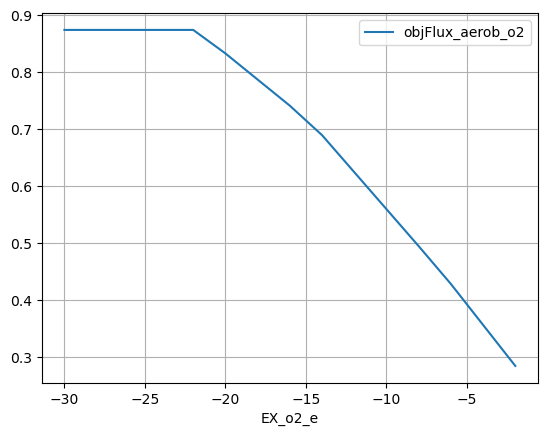

In [22]:
## your code ##
m_eco_core.medium=m_eco_core_media

## pandas import
import pandas as pd

## Function to compute optimization value with the row provided by the pandas apply function as argument
def get_rxnDepOptFlux(row, m, rxn):
    m.reactions.get_by_id(rxn).lower_bound = row[rxn]
    return m.slim_optimize()

## pandas data frame with column 1
data = {
  "EX_o2_e": range(-30,0,2)
}
data_df = pd.DataFrame(data)

## Using apply to add column 1 dependent optimized value
data_df['objFlux_aerob_o2'] = data_df.apply(get_rxnDepOptFlux, axis=1, args=(m_eco_core,'EX_o2_e'))

## plot the dependence
%matplotlib inline
data_df.plot(
    kind='line', x='EX_o2_e', y='objFlux_aerob_o2');
plt.grid()

## --- ##

What does the graphical output tell you with regards to optimal O2 flux?

>
> #### your answer
>


---

### Task 3.1 Influx screen | NH4 uptake 

Next to carbon sources, nitrogen sources are vital for growth.  
Repeat the sensitivity analysis to investigate the NH4 uptake in both the aerobic and the anaerobic models.


<Axes: title={'center': 'Aerob'}, xlabel='EX_nh4_e'>

<Axes: title={'center': 'Anaerob'}, xlabel='EX_nh4_e'>

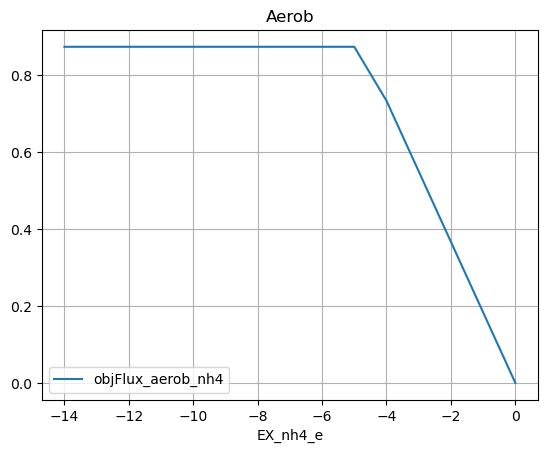

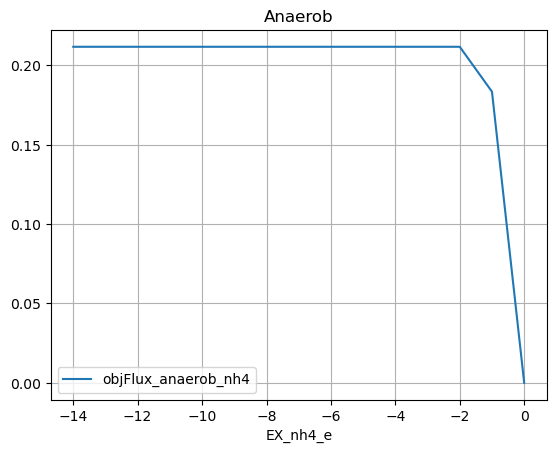

In [23]:
## your code ##
## make sure your model medium is standard for both the aerob and the anaerob model
m_eco_core_anaerob.medium = m_eco_core_anaerob_media
m_eco_core.medium = m_eco_core_media

#m_eco_core_anaerob.medium
#m_eco_core_anaerob.slim_optimize()

#m_eco_core.slim_optimize()

## create or modify pandas data frame
## data frame with column 1
data_df["EX_nh4_e"] =  range(-14, 1, 1)
#data_df = pd.DataFrame(data)
# m_eco_core.summary()

## Using apply to add column 1 dependent optimized value
data_df['objFlux_aerob_nh4'] = data_df.apply(get_rxnDepOptFlux, axis=1,  args=(m_eco_core,'EX_nh4_e'))
data_df['objFlux_anaerob_nh4'] = data_df.apply(get_rxnDepOptFlux, axis=1, args=(m_eco_core_anaerob, 'EX_nh4_e'))

## plot the dependence
%matplotlib inline
data_df.plot(kind='line', x='EX_nh4_e', y='objFlux_aerob_nh4', grid=1, title='Aerob')
data_df.plot(kind='line', x='EX_nh4_e', y='objFlux_anaerob_nh4', grid=1, title='Anaerob')

## --- ##

What qualitative and quantitative differences do you observe for NH4 dependent yields?

>
> #### your answer
>

--- 

## Task 4: Production envelopes

Instead of running our own simulations for finding out objective function dependence on metabolites, we can make use of so called production envelopes.

https://cobrapy.readthedocs.io/en/latest/phenotype_phase_plane.html

### Task 4.1 Prod. envel. | O2 dependence

- import the production_envelope (abbreviation: prenv) function
- Analyse and plot* prenv only for O2 exchange
- Analyse and plot* prenv only for O2 exchange together with glucose influx

*: plot the relationship of maximum flux over O2 flux

Make sure your model has default input fluxes as provided by the model import above by checking e.g. the <code>medium</code> property again.

Metabolite,Reaction,Flux,C-Number,C-Flux
glc__D_e,EX_glc__D_e,10,6,100.00%
nh4_e,EX_nh4_e,4.765,0,0.00%
o2_e,EX_o2_e,21.8,0,0.00%
pi_e,EX_pi_e,3.215,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
co2_e,EX_co2_e,-22.81,1,100.00%
h2o_e,EX_h2o_e,-29.18,0,0.00%
h_e,EX_h_e,-17.53,0,0.00%


<Axes: title={'center': 'Aerob model, O2'}, xlabel='EX_o2_e'>

<Axes: title={'center': 'Aerob model, O2, Glc'}, xlabel='EX_o2_e'>

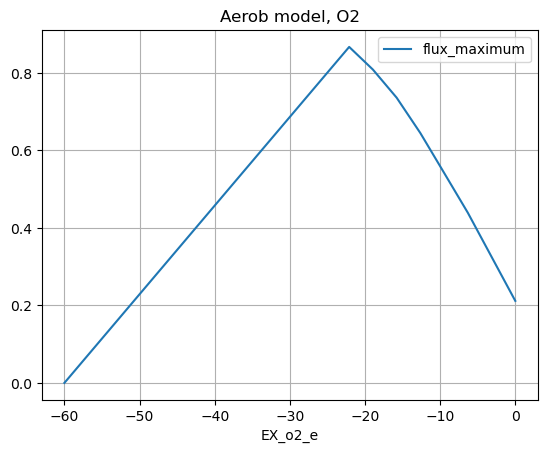

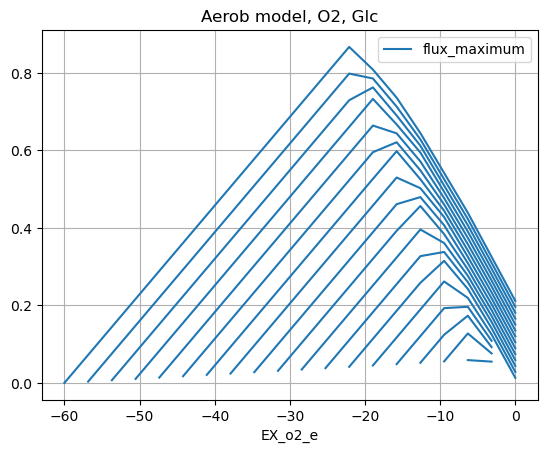

In [31]:
## your code ##
# import production envelopes
from cobra.flux_analysis import production_envelope as prenv

## optimize aerob model and print out summary
m_eco_core.medium = m_eco_core_media
#m_eco_core.slim_optimize()
#m_eco_core.medium
m_eco_core.summary()
aerobPrenvO2 = prenv(m_eco_core, ["EX_o2_e"])
#aerobPrenvO2
aerobPrenvO2Glc = prenv(m_eco_core, ["EX_glc__D_e", "EX_o2_e"])
#aerobPrenvO2Glc
## plot flux_maximum over O2 
%matplotlib inline
aerobPrenvO2.plot(kind='line', x='EX_o2_e', y='flux_maximum', title='Aerob model, O2', grid=1)
aerobPrenvO2Glc.plot(kind='line', x='EX_o2_e', y='flux_maximum', title='Aerob model, O2, Glc', grid=1)
#aerobPrenvO2Glc.plot(kind='line', x='EX_glc__D_e', y='flux_maximum', title='Aerob model, O2, Glc', grid=1)
## --- ##

How does the plot for O2 influx relate to the summary of the model optimisation?  
What relationship do you observe for the maximum O2 uptake and different Glucose uptake values?

>
> #### your answer
>

### Task 4.2 Prod. envel. | NH4 dependence

- For all four computeded production envelopes plot the relation of maximum carbon yield over the investigated exchange flux
- also investigate again the respective model optimisation summaries 

<Axes: title={'center': 'Aerob model, NH4, Glc'}, xlabel='EX_nh4_e'>

<Axes: title={'center': 'Anaerob model, NH4, Glc'}, xlabel='EX_nh4_e'>

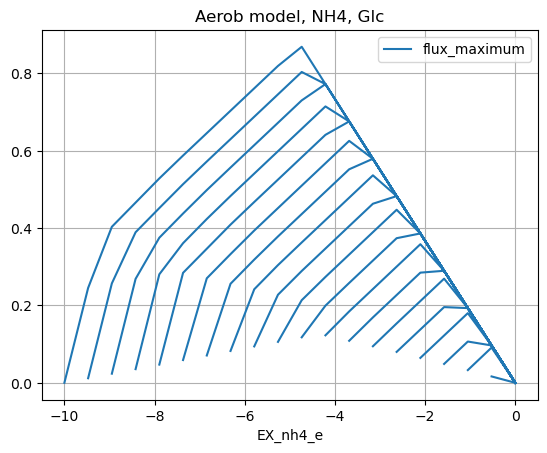

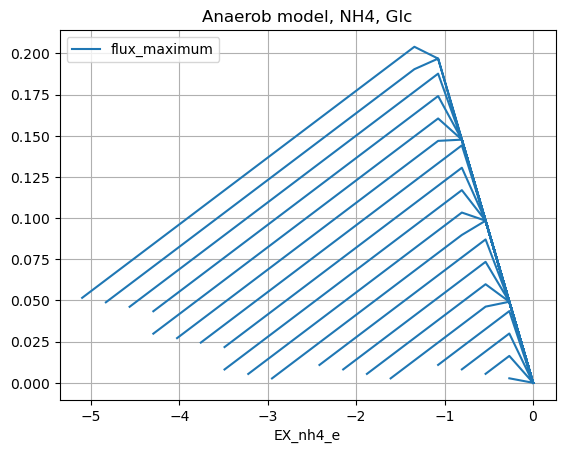

In [32]:
## your code ##

## optimize aerob model and print out summary
m_eco_core.medium = m_eco_core_media
m_eco_core_anaerob.medium = m_eco_core_anaerob_media

aerobPrenvNH4Glc = prenv(m_eco_core, ["EX_glc__D_e", "EX_nh4_e"])
anaerobPrenvNH4Glc = prenv(m_eco_core_anaerob, ["EX_glc__D_e", "EX_nh4_e"])

%matplotlib inline
aerobPrenvNH4Glc.plot(kind='line', x='EX_nh4_e', y='flux_maximum', 
                      title='Aerob model, NH4, Glc', grid=1)
anaerobPrenvNH4Glc.plot(kind='line', x='EX_nh4_e', y='flux_maximum', 
                        title='Anaerob model, NH4, Glc', grid=1)
## --- ##

What differences do you observe between aerob and anaerob behavior?

>
> #### your answer
>

---

In biotechnological setups, we commonly seek to produce a target product (metabolite) without severly affecting the host organism.
To streamline this analysis, we can also use phenotypic planes to assess byproduct optimality.



--- 

### Task 4.3 Production env. | Ethanol

Ethanol is a simple alcoholic compound with the chemical formula of C2H6O and has a variety of applications in chemical, food, medical and health industries.
See more details e.g. here: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6975068/

**Tasks**

- get the production envelope for the optimisation of Ethanol in the aerob and in the anaerob models
    - compute the production envelope for the reaction "Biomass_Ecoli_core"
    - use glucose as carbon source
- plot the envelopes

<Axes: title={'center': 'Aerob model, etoh'}, xlabel='Biomass_Ecoli_core'>

<Axes: title={'center': 'Anaerob model, etoh'}, xlabel='Biomass_Ecoli_core'>

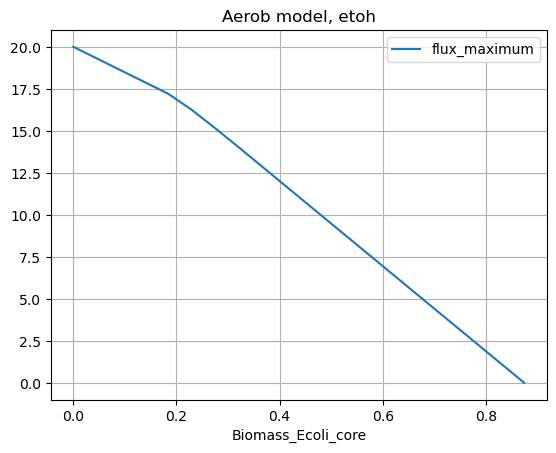

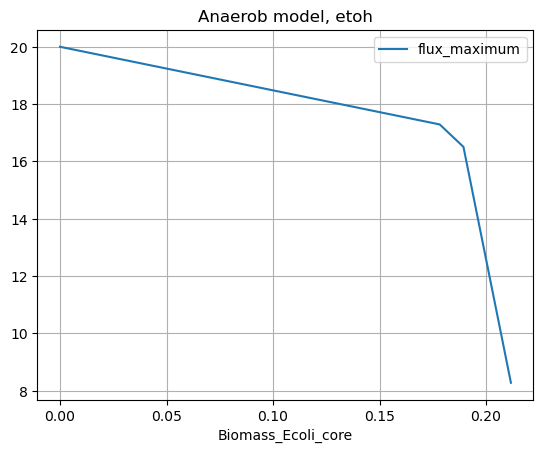

In [33]:
## your code ##
## optimize aerob model and print out summary
m_eco_core.medium = m_eco_core_media
m_eco_core_anaerob.medium = m_eco_core_anaerob_media

## aerob
prod_env_aerob = prenv(m_eco_core, objective="EX_etoh_e", 
                 reactions=[ "Biomass_Ecoli_core"], 
                 carbon_sources="EX_glc__D_e")
## prod_env_aerob
prod_env_aerob.plot(kind='line', x='Biomass_Ecoli_core', y='flux_maximum', title='Aerob model, etoh', grid=1)

## anaerob
prod_env_anaerob = prenv(m_eco_core_anaerob, objective="EX_etoh_e", 
                 reactions=[ "Biomass_Ecoli_core"], 
                 carbon_sources="EX_glc__D_e")
## prod_env_anaerob
prod_env_anaerob.plot(kind='line', x='Biomass_Ecoli_core', y='flux_maximum', title='Anaerob model, etoh', grid=1)

## --- ##

How does biomass relate to Ethanol production?  
How do you interpret the difference between aerob and anaerob growth regime?  
Are the results realistic?  

>
> #### your answer
>

---

## Task 5: Geometric FBA

We have learned that FBA solutions are not unique. Computing FVA is one way to work around this, however, we loose flux relationships this way.  
Another alternative to work with unique flux solutions is the computation of unique flux solutions via geometric FBA.  
Geometric FBA resembles all possible FBA solutions by geometric means and is in this way unique to a given problem.

**Tasks**
- Load the geometric FBA function from cobra.flux.analysis
- Summarise your results in a pandas data frame with the results of the following
    - Compute solutions for both the aerob and the anaerob model
    - Calculate the relative difference between both solutions ((solA-solB)/sum(solA,solB))
- Plot an ordered horizontal bar chart of the differences
    - Do not show flux differences, where reactions did not carry any flux in either growth regime
 

<Axes: >

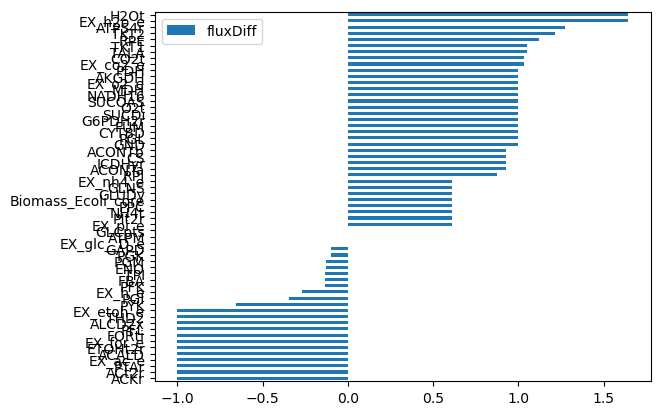

In [34]:
## your code ##

from cobra.flux_analysis import geometric_fba as gfba
m_eco_core.medium = m_eco_core_media
m_eco_core_anaerob.medium = m_eco_core_anaerob_media

## run gFBA
aer_gfba_sol = gfba(m_eco_core)
anaer_gfba_sol = gfba(m_eco_core_anaerob)

## summarize results in a pandas data frame
gfba_df = pd.DataFrame( {
    "aerobFlux" : aer_gfba_sol.fluxes,
    "anaerobFlux" : anaer_gfba_sol.fluxes}
                      )
## plot output
gfba_df["fluxDiff"] = (gfba_df["aerobFlux"]-gfba_df["anaerobFlux"])/(gfba_df["aerobFlux"]+gfba_df["anaerobFlux"])
gfba_df.dropna().sort_values(by="fluxDiff").plot(kind="barh", y="fluxDiff", use_index=True)
## --- ##

### Task 5.1 Ethanol production

Repeat the above task with the following constraints:
- maximum biomass yield is 0.1
- objective function = "EX_etoh_e"

Plot again the differences between aerob and anaerob growth conditions.

<Axes: >

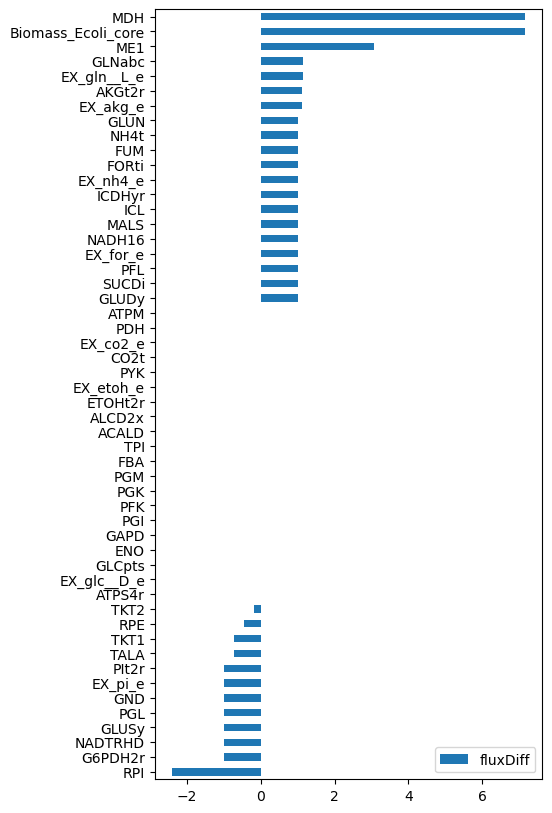

In [35]:
## your code ##

m_eco_core.medium = m_eco_core_media
m_eco_core_anaerob.medium = m_eco_core_anaerob_media

m_eco_core.reactions.Biomass_Ecoli_core.upper_bound = 0.1
m_eco_core_anaerob.reactions.Biomass_Ecoli_core.upper_bound = 0.1

m_eco_core.objective="EX_etoh_e"
m_eco_core_anaerob.objective="EX_etoh_e"


aer_gfbaEtoh_sol = gfba(m_eco_core)
anaer_gfbaEtoh_sol = gfba(m_eco_core_anaerob)

gfba_etoh_df = pd.DataFrame( {
    "aerobFlux" : aer_gfbaEtoh_sol.fluxes,
    "anaerobFlux" : anaer_gfbaEtoh_sol.fluxes}
                      )

gfba_etoh_df["fluxDiff"] = (gfba_etoh_df["aerobFlux"]-gfba_etoh_df["anaerobFlux"])/(gfba_etoh_df["aerobFlux"]+gfba_etoh_df["anaerobFlux"])
gfba_etoh_df.dropna().sort_values(by="fluxDiff").plot(kind="barh", y="fluxDiff", use_index=True, figsize=(5,10))
## --- ##

What do you observe?  
What does this say about geometric FBA?  
Can you use it to compare solutions of different growth regimes?  
Can you think of alternatives to crosscheck differences in feasible fluxes?

>
> #### your answer
>

---

### Task 5.2 Assess running time for FBA vs gFBA vs pFBA

You may think, if gFBA is one instance of all possible FBA derived solutions, why is this not the standard? 
After all it optimises the flux towards a reproducible result and that must be a good thing.  
Or why are we not looking at loopless solutions or solutions with minimal fluxes?

Let's look into the runtimes of several approaches with different assumptions.

**Task**

- Compute within a loop 5x the optimisation with all three tools and track the runtime
    - Use the time class to track the time
- save your runtimes into a pandas dataframe
- plot the runtimes as bar-chart

**Note:** While loopless FBA tries to find true solutions without any looping flux, pFBA minimizes flux, but in theory also allows looping flux.

[<Solution 20.000 at 0x7f21418b37d0>,
 <Solution 20.000 at 0x7f214177ead0>,
 <Solution 20.000 at 0x7f2141757590>,
 <Solution 20.000 at 0x7f214176d690>,
 <Solution 20.000 at 0x7f214176e250>]

[<Solution 20.000 at 0x7f2141781510>,
 <Solution 20.000 at 0x7f21417a7e50>,
 <Solution 20.000 at 0x7f21417d05d0>,
 <Solution 20.000 at 0x7f21417e89d0>,
 <Solution 20.000 at 0x7f2141604dd0>]

[<Solution 320.000 at 0x7f21416051d0>,
 <Solution 320.000 at 0x7f21416432d0>,
 <Solution 320.000 at 0x7f2141643bd0>,
 <Solution 320.000 at 0x7f2141658490>,
 <Solution 320.000 at 0x7f2141658d10>]

[<Solution 0.000 at 0x7f2141613010>,
 <Solution 0.000 at 0x7f2141b0f7d0>,
 <Solution 0.000 at 0x7f2161c00a10>,
 <Solution 0.000 at 0x7f2141722d10>,
 <Solution 0.000 at 0x7f21419b5c10>]

{'FBA': 0.032145023345947266,
 'looplessFBA': 0.31094908714294434,
 'pFBA': 0.1899116039276123,
 'gFBA': 8.382235527038574}

Time regular FBA: 0.03 sec.
Time loopless FBA: 0.31 sec.
Time pFBA: 0.19 sec.
Time gFBA: 8.38 sec.


,method,runtimes
0,FBA,0.032145
1,looplessFBA,0.310949
2,pFBA,0.189912
3,gFBA,8.382236


<Axes: >

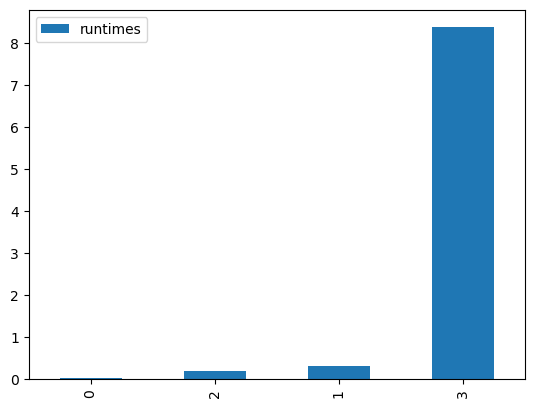

In [36]:
## your code ##
## import classes if necessary
from cobra.flux_analysis import geometric_fba as gfba
from cobra.flux_analysis import pfba
from cobra.flux_analysis.loopless import loopless_solution as loopless_sol
import time

 
## run the computations and track the times in a dictionary
runtimes_dict = dict()
start = time.time()
[m_eco_core.optimize() for i in range(5)];
t_run1 = time.time()
[loopless_sol(m_eco_core) for i in range(5)];
t_run2 = time.time()
[pfba(m_eco_core) for i in range(5)];
t_run3 = time.time()
[gfba(m_eco_core) for i in range(5)];
t_run4 = time.time()
runtimes_dict["FBA"]=t_run1 - start
runtimes_dict["looplessFBA"]=t_run2 - t_run1
runtimes_dict["pFBA"]=t_run3 - t_run2
runtimes_dict["gFBA"]=t_run4 - t_run3
runtimes_dict
print("Time regular FBA: {:.2f} sec.".format(runtimes_dict["FBA"]))
print("Time loopless FBA: {:.2f} sec.".format(runtimes_dict["looplessFBA"]))
print("Time pFBA: {:.2f} sec.".format(runtimes_dict["pFBA"]))
print("Time gFBA: {:.2f} sec.".format(runtimes_dict["gFBA"]))

## gather information into pandas dataframes
runtimes_df = pd.DataFrame({
    "method" : ["FBA", "looplessFBA","pFBA", "gFBA"]    
} )
runtimes_df = runtimes_df.assign(runtimes=runtimes_dict.values())
runtimes_df
## plot results in a pie chart
runtimes_df.sort_values(by='runtimes').plot(
    kind='bar', 
    y='runtimes'
    )
## --- ##

What does the plot tell you?  
Contextualize your answer with the model and its size you are using today.

>
> #### your answer
>

---

## Additional (optional) tasks: 
1. Compute FVA for problem 5 and compare lower and upper bounds of flux carrying reactions.

In biotech we often want to have a maximum growth first and then "switch" the production organism to cease growth, but overproduce a metabolite.

Based on FVA, which reactions (and thus genes) can be knocked out to keep growth low, but ethanol production high (at least 80% of the theoretical maximum)?  

Is this different for aerob and anaerob growth conditions?

Is this result more or less robust than a result on gFBA or pFBA?

---

2. Compute MOMA
MOMA stands for "Minimization of metabolic adjustment". The tool does exactly what the name hints.

- Optimise and save the flux distribution in a variable without any perturbation
- Identify non-essential reactions for ethanol production of at least 50% of its theoretical best yield.
- Choose a non-essential reaction, knock it out and re-run your FBA (or pFBA, or gFBA)
    - sum up the overall absolute flux change compared to the original flux distribution, may it be negative or positive
- run MOMA analysis on the perturbed system (check documentation for how to run it)
    - again sum up the flux differences
- Compare the results by MOMA compared to FBA solutions. Is MOMA a better approach than FBA (or its derivatives)?  